## Análisis de datos II - Clase 2
---

### SHAP para explicar una regresión lineal
---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn import linear_model

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import shap

### DATOS

In [2]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)

X = diabetes.data
y = diabetes.target

In [3]:
# X, y = shap.datasets.diabetes()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_test.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
362,0.019913,0.050680,0.104809,0.070072,-0.035968,-0.026679,-0.024993,-0.002592,0.003709,0.040343
249,-0.012780,-0.044642,0.060618,0.052858,0.047965,0.029375,-0.017629,0.034309,0.070207,0.007207
271,0.038076,0.050680,0.008883,0.042529,-0.042848,-0.021042,-0.039719,-0.002592,-0.018114,0.007207
435,-0.012780,-0.044642,-0.023451,-0.040099,-0.016704,0.004636,-0.017629,-0.002592,-0.038460,-0.038357
400,-0.023677,-0.044642,0.045529,0.090729,-0.018080,-0.035447,0.070730,-0.039493,-0.034522,-0.009362


### Entrenamos una regresión lineal

In [4]:
lin_regr = linear_model.LinearRegression()
lin_regr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [5]:
y_pred = lin_regr.predict(X_test)

print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²  : {r2_score(y_test, y_pred):.3f}")

MAE : 46.17
RMSE: 58.52
R²  : 0.332


#### ¿Cómo hace el modelo para predecir el valor para la primera observación del dataset de test?

In [6]:
i = 0

tabla = pd.DataFrame({
    "Feature": X_train.columns,
    "Valor": X_test.iloc[i].values,
    "Coeficiente": lin_regr.coef_
})

tabla["Término"] = tabla["Valor"] * tabla["Coeficiente"]

tabla = tabla.reindex(
    tabla["Término"].abs().sort_values(ascending=False).index
)

display(tabla)

print(f"Intercepto: {lin_regr.intercept_:.2f}")
print(f"Suma contribuciones: {tabla['Término'].sum():.2f}")
print(f"Predicción: {lin_regr.predict(X_test.iloc[[i]])[0]:.2f}")

,Feature,Valor,Coeficiente,Término
2,bmi,0.104809,562.762347,58.982384
4,s1,-0.035968,-662.702901,23.835953
3,bp,0.070072,305.463482,21.404529
1,sex,0.050680,-243.165090,-12.323636
5,s2,-0.026679,324.207385,-8.649497
8,s5,0.003709,731.637435,2.713687
9,s6,0.040343,43.030931,1.736013
0,age,0.019913,-35.550251,-0.707920
6,s3,-0.024993,24.748795,-0.618538
7,s4,-0.002592,170.324962,-0.441527


Intercepto: 152.54
Suma contribuciones: 85.93
Predicción: 238.47


#### SHAP expresa esta misma idea, pero usando un valor base y contribuciones.

In [7]:
explainer = shap.LinearExplainer(lin_regr, X_train)     # LinearExplainer() es el Explainer recomendado para modelos lineales
explanation = explainer(X_test)

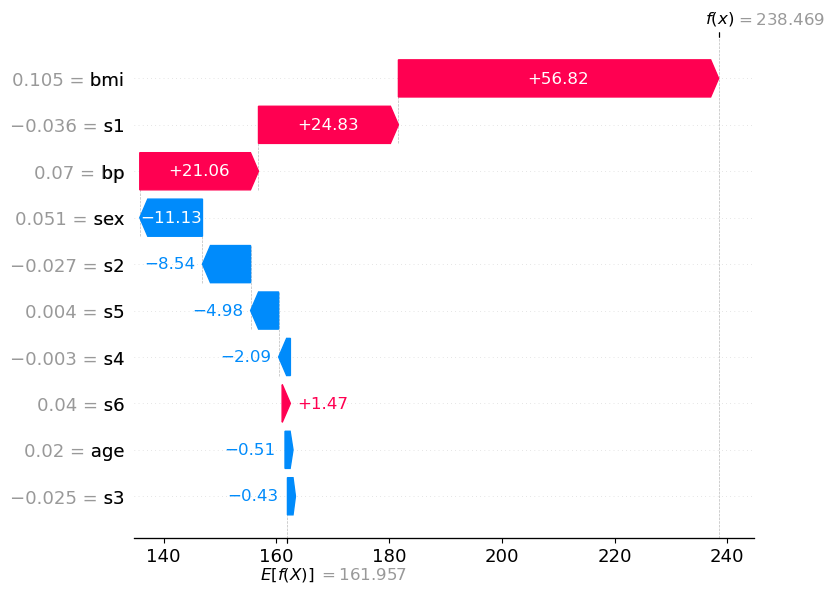

In [8]:
shap.plots.waterfall(explanation[0, :])

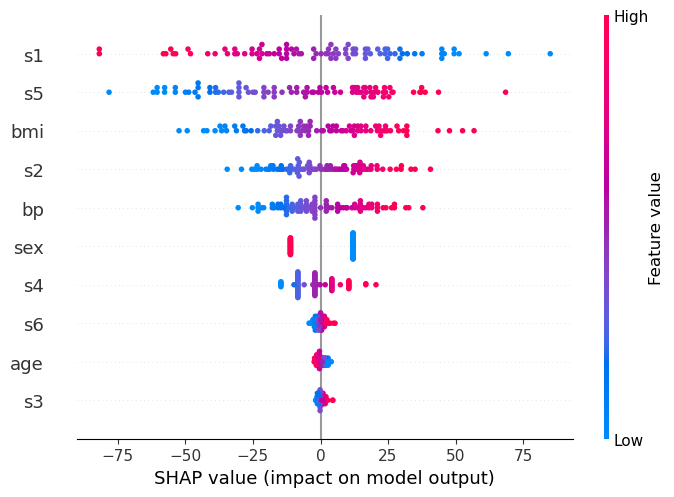

In [9]:
shap.plots.beeswarm(explanation)

¿Tiene sentido lo que muestra el plot? ¿Es consistente con un modelo de regresión lineal?

**Los SHAP values son esencialmente las contribuciones lineales de cada variable (coeficiente × desviación respecto del valor de referencia).**